<div style="text-align: center;" >
<h1 style="margin-top: 0.2em; margin-bottom: 0.1em;">Introduction to Computation for the Social Sciences</h1>
<h2 style="margin-top: 0.7em; margin-bottom: 0.3em;">Assignment 4</h2>
<h3 style="margin-top: 0.7em; margin-bottom: 0.3em;">Deadline: 26.01.2025 23:59</h3>

<h2 style="margin-top: 0.7em; margin-bottom: 0.3em; color: red"> A Possible Solution </h2>
<h3 style="margin-top: 0.7em; margin-bottom: 0.3em; color: orange"> Solution checked in December 2025 </h3>

</div>
<br>

<h4 style="margin-top: 0.7em; margin-bottom: 0.3em; font-style:italic">
Please push your solutions to your personal repository in our <a href='https://classroom.github.com/a/xjo-U8gM'>GitHub Classroom</a></h4><br>

***

In this assignment, you will implement runtime comparisons and improvements of algorithms. Additionally, you will have to create, load and query a database using SQLite.<br>

As always: In case of questions feel free to reach out to us tutors in person, via mail, or over discord as soon, as you face an issue!<br>

***Important: Submit a solution for every single task and do not skip any of them. Even if your solution is not perfect or doesn't work you might still receive some points that way!***


***

In [1]:
# Import the modules you use throughout the assignment here (this is called a setup chunk/cell)
# e.g import pandas as pd
# e.g import numpy as np and so on...

import pandas as pd
import time
import matplotlib.pyplot as plt
import math
import random
import pymysql
import requests
import ast  # Safely evaluate strings as Python literals
import os
import sqlite3

***

# Part 1 - Sorting and Runtime Analysis


In GitHub, you will find a dataset on empirical conflict data (ACLED_South-Sudan_2017.csv).
We are going to use this data set in order to compare runtime gains from efficient and systematic comparison of time-stamped data.

*Note:* Please use the ``event_date`` column for timestamp and use the Python module ``time`` to **track runtimes**.


- Begin by writing a simple function ``sliding_window()`` that takes a dataframe and an integer X as inputs and checks for each pair of events (their given timestamp in ``event_date``) whether they lie within the X days of each other (before and after, inclusive). The function should, for each event, return a list of those events (i.e the id) that do lie within the timeframe.
    * for example: the event with ID 'SSD5376' has the following events within a range of two days: ['SSD5373', 'SSD5374', 'SSD5375', 'SSD5372']
- Then, we write a new function `sliding_window_optimized()`, which improves the runtime of the frist function by *first sorting* the data by timestamp and then doing the comparison by iterating through the sorted index of events (forward and backward). In doing so, we use the minimal number of steps to decide if an event before or after a given event in the index is within our X-day window.
- Systematically compare the runtime of the two variants (for different window-sizes) and vizualize the results.

## Task 1.1


Write the ``sliding_window()`` function. (Not optimized - use a naiive algorithm)

In [2]:
# load the data
conflict_data = pd.read_csv('data/ACLED_South-Sudan_2017.csv')

In [3]:
# Your code
# first transform the event_date column into a date format
conflict_data['event_date_datetime'] = pd.to_datetime(conflict_data['event_date'], format='%d %B %Y')

In [4]:
# Sliding Window Function + application

def sliding_window(data, col_time, col_id, window_size):
    """
    Function checks inside a dataframe with a time and an id-column which (other) events are in the predefined time window of an event.
    
    Parameters
    ----------
    data: Pandas DataFrame
        the dataframe with the events
        
    col_time: datetime 
        name of the data's column with the date of the event as an datetime-object 

    col_id: string
        name of the column with the ids of the events

    window_size: int
        time window in days (backwards and forwards - e.g windowsize = 2 means two days prior to the event and two days after the event) 
    
    Returns
    -------
    List
        the list contains for each a event a list with all events inside the predefined time period
    
    """
    # iniciate an empty list for the return
    events_intime = []

    # loop over each event (this is the loop for the events that we build the timeframe around)
    for i in range(len(data)):
        event_date = data[col_time].iloc[i]
        # add an empty list to be filled with the ids that are inside the timeframe of the current event
        events_intime.append([])
        
        # loop over all events again, this time to check whether an event is inside the timeframe of the current event
        for j in range(len(data)):
            other_date = data[col_time].iloc[j]
            
            # event ids get added to the list of the current event, if the distance between the event inside the predefined range and its not the current event itself
            if abs((event_date - other_date).days) <= window_size and i != j:
                #print(f'event: {event_date}, other: {other_date} delta:{abs(((event_date - other_date).days))} evaluation: {abs(((event_date - other_date).days) <= window_size)}')
                events_intime[i].append(data[col_id].iloc[j])
    return events_intime

# try the function with window_size = 2
sliding_window(conflict_data, 'event_date_datetime', 'event_id_cnty', 2)

[['SSD5373', 'SSD5374', 'SSD5375', 'SSD5372'],
 ['SSD5376', 'SSD5374', 'SSD5375', 'SSD5372', 'SSD5371'],
 ['SSD5376', 'SSD5373', 'SSD5375', 'SSD5372', 'SSD5371'],
 ['SSD5376', 'SSD5373', 'SSD5374', 'SSD5372', 'SSD5371'],
 ['SSD5376', 'SSD5373', 'SSD5374', 'SSD5375', 'SSD5371', 'SSD5369', 'SSD5370'],
 ['SSD5373',
  'SSD5374',
  'SSD5375',
  'SSD5372',
  'SSD5369',
  'SSD5370',
  'SSD5367',
  'SSD5368'],
 ['SSD5372', 'SSD5371', 'SSD5370', 'SSD5367', 'SSD5368', 'SSD5365', 'SSD5366'],
 ['SSD5372', 'SSD5371', 'SSD5369', 'SSD5367', 'SSD5368', 'SSD5365', 'SSD5366'],
 ['SSD5371', 'SSD5369', 'SSD5370', 'SSD5368', 'SSD5365', 'SSD5366', 'SSD5364'],
 ['SSD5371', 'SSD5369', 'SSD5370', 'SSD5367', 'SSD5365', 'SSD5366', 'SSD5364'],
 ['SSD5369',
  'SSD5370',
  'SSD5367',
  'SSD5368',
  'SSD5366',
  'SSD5364',
  'SSD5350',
  'SSD5351',
  'SSD5363'],
 ['SSD5369',
  'SSD5370',
  'SSD5367',
  'SSD5368',
  'SSD5365',
  'SSD5364',
  'SSD5350',
  'SSD5351',
  'SSD5363'],
 ['SSD5367',
  'SSD5368',
  'SSD5365',

## Task 1.2 


Write the optimized function `sliding_window_optimized()` by first sorting the data accoding to the time-stamp.


In [5]:
def sliding_window_optimized(data, col_time, col_id, window_size):
    """
    Function checks inside a dataframe with a time and an id-column which (other) events are in the predefined time window of an event.
    
    Parameters
    ----------
    data: Pandas DataFrame
        the dataframe with the events
        
    col_time: datetime 
        name of the data's column with the date of the event as an datetime-object 

    col_id: string
        name of the column with the ids of the events

    window_size: int
        time window in days (backwards and forwards - e.g windowsize = 2 means two days prior to the event and two days after the event) 
    
    Returns
    -------
    List
        the list contains for each a event a list with all events inside the predefined time period
    
    """
    # sort the df by their timestamp descending - avoid bugs in case the df given is not sorted yet
    # only keep columns of relevance
    sorted = data[[col_time, col_id]].sort_values(by=col_time, ascending=False)
    
    # iniciate an empty list for the return
    events_intime = []

     # loop over each event (this is the loop for the events that we build the timeframe around)
    for i in range(len(sorted)):
        event_date = sorted[col_time].iloc[i] # first date that we are looking for events for
        events_intime.append([]) # add an empty list for the event-ids inside the window of the above stored event_date 
        
        # iniciate j as the index of the next event in the df (due to ordering the event, the event directly before the current event)
        j = i+1

        # loop to go over each event before the current event (from closest, if the current event is not already the earliest event - to the last one that is still inside the predefined time window) 
        # and adds them to the ids list of the current event
        while j < len(sorted) and abs((event_date - sorted[col_time].iloc[j]).days) <= window_size:
            events_intime[i].append(data[col_id].iloc[j])
            j = j+1
        
        
        # first we check if there are any events after the current event
        if(i > 0):
            # if so, we set j to be the index for the next event after the current event 
            j = i-1

            # now a loop runs after each event after the current event, as long as the events are still inside the predefined timeframe
            # and adds them to the ids list of the current event.
            while abs((event_date - sorted[col_time].iloc[j]).days) <= window_size:
                events_intime[i].append(data[col_id].iloc[j])
                j = j-1

    return events_intime


# apply function
sliding_window_optimized(data = conflict_data, col_time='event_date_datetime', col_id='event_id_cnty', window_size=2)



[['SSD5373', 'SSD5374', 'SSD5375', 'SSD5372'],
 ['SSD5374', 'SSD5375', 'SSD5372', 'SSD5371', 'SSD5376'],
 ['SSD5375', 'SSD5372', 'SSD5371', 'SSD5373', 'SSD5376'],
 ['SSD5372', 'SSD5371', 'SSD5374', 'SSD5373', 'SSD5376'],
 ['SSD5371', 'SSD5369', 'SSD5370', 'SSD5375', 'SSD5374', 'SSD5373', 'SSD5376'],
 ['SSD5369',
  'SSD5370',
  'SSD5367',
  'SSD5368',
  'SSD5372',
  'SSD5375',
  'SSD5374',
  'SSD5373'],
 ['SSD5370', 'SSD5367', 'SSD5368', 'SSD5365', 'SSD5366', 'SSD5371', 'SSD5372'],
 ['SSD5367', 'SSD5368', 'SSD5365', 'SSD5366', 'SSD5369', 'SSD5371', 'SSD5372'],
 ['SSD5368', 'SSD5365', 'SSD5366', 'SSD5364', 'SSD5370', 'SSD5369', 'SSD5371'],
 ['SSD5365', 'SSD5366', 'SSD5364', 'SSD5367', 'SSD5370', 'SSD5369', 'SSD5371'],
 ['SSD5366',
  'SSD5364',
  'SSD5350',
  'SSD5351',
  'SSD5363',
  'SSD5368',
  'SSD5367',
  'SSD5370',
  'SSD5369'],
 ['SSD5364',
  'SSD5350',
  'SSD5351',
  'SSD5363',
  'SSD5365',
  'SSD5368',
  'SSD5367',
  'SSD5370',
  'SSD5369'],
 ['SSD5350',
  'SSD5351',
  'SSD5363',

## Task 1.3

Systematically compare the runtime of both functions for different window sizes and visualize you results. 

In [6]:
# create 'sceleton' of the dataframe to store the runtime for each window size
# runtime_original is for the first 'naive' function (sliding_window) and runtime_optimal for the sliding_window_optimized 

runtime_comparison = pd.DataFrame(columns = ['window_size', 'runtime_original', 'runtime_optimal'])
runtime_comparison.window_size = range(1, 6)

runtime_comparison


,window_size,runtime_original,runtime_optimal
0,1,NaN,NaN
1,2,NaN,NaN
2,3,NaN,NaN
3,4,NaN,NaN
4,5,NaN,NaN


In [9]:
# create runtime data for both functions

# loops over the length of the df and therefore quasi over the windowsizes
for i in range(len(runtime_comparison)):
    
    start_time = time.time() # store start time
    # let the optimized function run with the current window size
    sliding_window_optimized(data = conflict_data, col_time='event_date_datetime', col_id='event_id_cnty', window_size= i + 1)
    end_time = time.time() # store end time

    # store the difference between start and end time aka runtime in the appropriate cell in the runtime_comaprison df
    runtime_comparison.loc[i, 'runtime_optimal'] = end_time - start_time

    # same procedure as above , but with the original function
    start_time = time.time()
    sliding_window(data = conflict_data, col_time='event_date_datetime', col_id='event_id_cnty', window_size= i + 1)
    end_time = time.time()

    runtime_comparison.loc[i, 'runtime_original'] = end_time - start_time


# check out the df 
runtime_comparison

,window_size,runtime_original,runtime_optimal
0,1,20.859099,0.263663
1,2,20.668579,0.30212
2,3,20.711775,0.402169
3,4,20.781834,0.505081
4,5,20.999815,0.608351


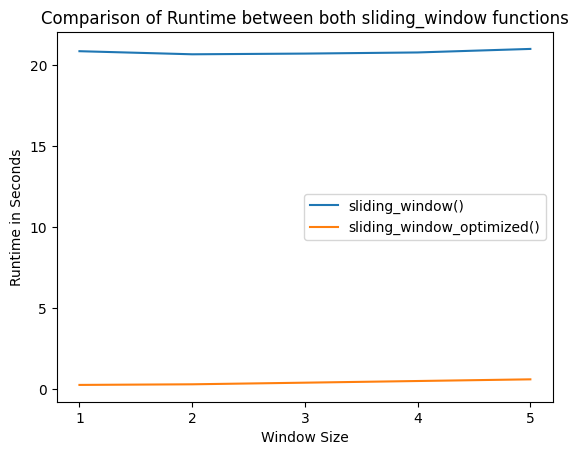

In [12]:
# Visualization

# create plot with two lines
runtime_comparison.plot(
    x='window_size', 
    y=['runtime_original', 'runtime_optimal'], 
    kind='line')

# Adding labels and title
plt.xlabel('Window Size')
plt.ylabel('Runtime in Seconds')
plt.title('Comparison of Runtime between both sliding_window functions')

# Fix x-axis ticks to integers
plt.xticks(runtime_comparison['window_size'])

# Show the legend
plt.legend(['sliding_window()', 'sliding_window_optimized()'])



***
# Part 2 - Runtime of Sorting Algorithms





## Task 2.1



In this task, we want to compare runtime of two sorting-algorithms. Again, please use ``time`` to measure the runtime.

Therefore:

- Implement the Selection Sort Algorithm, learned in the lecture, for a list-input
- Implement the Merge Sort Algorithm, learned in the lecture, for a list-input
- Compare the runtime on lists of different length (i.e. 1.000, 2.0000, 3.000 up to 10.000) with random integers.
- Visualize the runtimes in a plot 

In [13]:
# Selection Sort

def selection_sort(list):
    """
    Function sorts a list of values using the Selection Sort Algorithm
    
    Parameters
    ----------
    list: List
        list with the values that have to be sorted
    
    Returns
    -------
    List
        returns the entered list with the values sorted in ascending order
    
    """
    
    for i in range(len(list)-1): # last element at the end of the loop is already has the highest value
        m = i # store current value as the temporary minimum

        for j in range(i +1, len(list)): # run through the unsorted part of the list
            if list[j] < list[m]: # check whether there is a value smaller than the current minimum
                m = j # if yes, set that value to be the new minimum
    
        # swap the minimum of unsorted part of the list with the current value (value on the index i)
        temp = list[m]
        list[m] = list[i]
        list[i] = temp
        # print(list)
    
    return list


# apply function
selection_sort([512, 87,503,61,908,170,897])


[61, 87, 170, 503, 512, 897, 908]

In [16]:
def merge_sort(A, p, r):
    """
    Function sorts a list of values using the Merge Sort Algorithm 
    (it expects a second function that merges the sorted sublist together)

    Parameters
    ----------
    A: List
        list with the values that have to be sorted

    p: integer
        the first index of the list to be sorted

    r: integer
        the last index of the list to be sorted
    
    Returns
    -------
    List
        returns the entered list with the values sorted in ascending order
    
    """

    if p < r:                          # base case: there are values to be sorted (part of the list that needs sorting is at least size 1) - recursion stops if this case is not met
        q = math.floor((p+r)/2)        # find the middle point of the part of the list to be sorted
        merge_sort(A, p, q)            # call mergesort (recursively) on the left side on the list (part to be sorted)
        merge_sort(A, q+1, r)          # dito but on the right side
        merge(A, p, q, r)              # merge the sorted list back together (more precisely: merge the part of the lists that are already sorted together)
    
    return A

def merge(A, p, q, r):
    """
    Function merges two sublists (in our context these sublists are sorted) into a sorted list 

    Parameters
    ----------
    A: List
        list with the values that have to be sorted

    p: integer
        the starting index of the left sublist that needs to be merged

    q: integer
        the cutoff index seperating the two sublists to be merged 

    r: integer
        the end index of the sublist that needs to be merged
    
    
    Returns
    -------
    List
        returns the entered list with the values sorted in ascending order
    
    """
    n1 = q-p+1 # first index out of bounce for the left array 
    n2 = r-q   # first index out of bounce for the right array 

    
    B = A[p:q+1]  # temporary storage of the left array
    C = A[q+1:r+1] # temporary storage of the right array


    i = j = 0      # set indices for the left array (i) and right array (j) to 0
    k = p          # inizialice the index k for the merged list
    #print(k)
    #print(A)

    while i < n1 and j < n2:   # as long as i and j both still have elements inside their part of the list to be processed
        if B[i] >= C[j]:       # if the current element of the left side is smaller than the current element on the right side 
            A[k] = B[i]        # the current element of the merged list is the current left side element
            i += 1             # index i raises by one (next element on the left side list is the new current element for the left side)
        else:
            A[k] = C[j]        # if the current element of the right side is smaller, than the current element of the merged list is the current right side element
            j += 1             # respectively, the index j raises by one (next element on the right side list is the new current element for the right side)
        k += 1                 # no matter whether the left or right had the smaller element, the index of the merged list gets raised by one 
        

    # copy remainings from the left (if there are 1 or more elements on the left side that are bigger than every element of the rigth side they have to be moved to the merged list)
    while i < n1:
        A[k] = B[i]
        i += 1
        k += 1
    
    # copy remainings from the right (if there are 1 or more elements on the right side that are bigger than every element of the left side they have to be moved to the merged list)
    while j < n2:
        A[k] = C[j]
        j += 1
        k +=1

            

# apply function
print(merge_sort([512, 87, 503, 61, 908, 170, 897], 0, 6))

[908, 897, 512, 503, 170, 87, 61]


In [20]:
list(range(1000, 10001, 1000))

[1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

In [21]:
# create 'sceleton' of the dataframe to store the runtime for each list length
runtime_sort = pd.DataFrame(columns = ['list_length', 'runtime_selectionSort', 'runtime_mergeSort'])
runtime_sort.list_length = list(range(1000, 10001, 1000))



# create runtime data for both functions

# create seed
random.seed(42)

# loops over the list lengths
for index, value in enumerate(list(range(1000, 10001, 1000))):

    list_random =[random.randint(1, 1000) for _ in range(value)] # create a list with random values (amount specified by loop var 'value')
    
    start_time = time.time() # store start time
    # use selection sort to sort the list
    selection_sort(list_random)
    end_time = time.time() # store end time

    # store the difference between start and end time aka runtime in the appropriate cell in the runtime_sort df
    runtime_sort.loc[index, 'runtime_selectionSort'] = end_time - start_time

    # same procedure as above , but with the merge_sort function
    start_time = time.time()
    merge_sort(list_random, 0, value-1)
    end_time = time.time()

    runtime_sort.loc[index, 'runtime_mergeSort'] = end_time - start_time


# check out the df 
runtime_sort 

,list_length,runtime_selectionSort,runtime_mergeSort
0,1000,0.018558,0.000642
1,2000,0.040866,0.001343
2,3000,0.092488,0.002084
3,4000,0.161524,0.002838
4,5000,0.254871,0.003726
5,6000,0.381962,0.004429
6,7000,0.505663,0.005271
7,8000,0.653992,0.006027
8,9000,0.834098,0.006865
9,10000,1.078871,0.008042


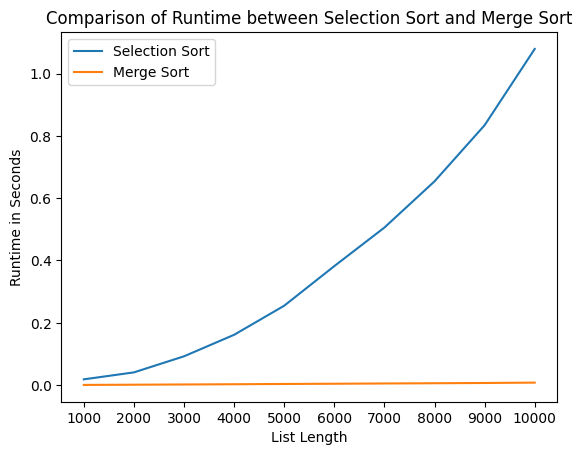

In [22]:
# Visualization

# create plot with two lines
runtime_sort.plot(x='list_length', y=['runtime_selectionSort', 'runtime_mergeSort'], kind='line')

# Adding labels and title
plt.xlabel('List Length')
plt.ylabel('Runtime in Seconds')
plt.title('Comparison of Runtime between Selection Sort and Merge Sort')

# Fix x-axis ticks to integers
plt.xticks(runtime_sort['list_length'])

# Show the legend
plt.legend(['Selection Sort', 'Merge Sort'])

## Task 2.2 


Now, test the runtime of (**only**) mergesort on lists of 100.000 up to 1.000.000 (in intervals of 100.000). Test different input cases:

- A list of random integers
- A list of sortes integers in descending order
- A list of sorted integers in ascending order

Again, please visualize the results.

In [23]:
# Set up the df
runtime_MergeSort = pd.DataFrame(columns = ['list_length', 'runtime_random', 'runtime_descending', 'runtime_ascending'])
runtime_MergeSort.list_length = list(range(100000, 1000000 +1, 100000))


# create runtime data for both functions

# create seed
random.seed(42)

# loops over the list lengths
for index, value in enumerate(list(range(100000, 1000000 +1, 100000))):

    # sort a random list
    list_random =[random.randint(1, 1000) for _ in range(value)] # create a list with random values (amount specified by loop var 'value')

    start_time = time.time() # store start time
    # let the merge_sort function run with a list of random numbers
    merge_sort(list_random,  0, value-1)
    end_time = time.time() # store end time

    # store the difference between start and end time aka runtime in the appropriate cell in the runtime_MergeSort df
    runtime_MergeSort.loc[index, 'runtime_random'] = end_time - start_time

    

    # sort a descending list
    list_des = list(range(value, 0, -1)) # create a list with descending values

    start_time = time.time()
    merge_sort(list_des, 0, value-1)
    end_time = time.time()

    runtime_MergeSort.loc[index, 'runtime_descending'] = end_time - start_time

    
    # sort a ascending list
    list_as = list(range(value)) # create a list with ascending values
    
    start_time = time.time()
    merge_sort(list_as, 0, value-1)
    end_time = time.time()

    runtime_MergeSort.loc[index, 'runtime_ascending'] = end_time - start_time

# check out the df 
runtime_MergeSort 

,list_length,runtime_random,runtime_descending,runtime_ascending
0,100000,0.112484,0.087812,0.086635
1,200000,0.238462,0.184756,0.18188
2,300000,0.379758,0.28546,0.285874
3,400000,0.515838,0.390059,0.382663
4,500000,0.682368,0.507754,0.489943
5,600000,0.852635,0.60182,0.596119
6,700000,1.011828,0.706669,0.69596
7,800000,1.134334,0.810256,0.801803
8,900000,1.357952,0.92825,0.910873
9,1000000,1.480424,1.045797,1.038858


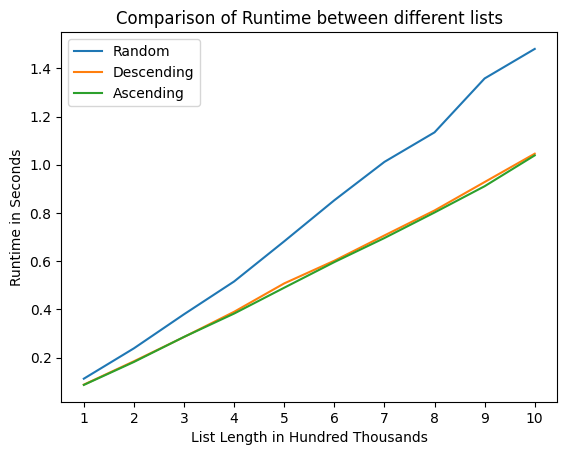

In [30]:
# Visualization

# create plot with three lines
runtime_MergeSort.plot(x='list_length', y=['runtime_random', 'runtime_descending', 'runtime_ascending'], kind='line')

# Adding labels and title
plt.xlabel('List Length in Hundred Thousands')
plt.ylabel('Runtime in Seconds')
plt.title('Comparison of Runtime between different lists')

# Fix x-axis ticks to integers
ticks = runtime_MergeSort['list_length']
labels = [int(x / 100000) for x in ticks]
plt.xticks(ticks, labels)

# Show the legend
plt.legend(['Random', 'Descending', 'Ascending'])

***
# Part 3 - Relational Databases 
### (SQLite)

## Task 3.1 *Pen-On-Paper*: Create a relational schema

### The Relational Model
Design a relational schema for a movie database.
Your schema should include the following:
- Movies and their attributes <br>
(make sure to include all attributes you will need to answer the questions in the following subtasks)
- Genres and their relationship to movies.
- Directors and their relationship to movies.

Please, provide a pictue of your schema as a __pdf file__ (Feel free to write it on a paper and scan it). <br>
As learned in the lecture. Think about how to relate the tables/relations to each other to avoid redundancies. Make sure to demonstrate the primary key for each relation/table and show all foreign key relations.
Optionally, you can also provide the data types/domains for each column(attribute) - Thinking about this early on will make your life easier when implementing the schema later.

### The data:

1. __bechdel_tmdb__:
- Contains information about movies, including titles, release dates, ratings, genres and Bechdel test scores.
- It is the ['Bechdel Test Movie List'](https://bechdeltest.com/) enhanced with information regarding the movies from the [The Movie DB - TMDB](https://www.themoviedb.org/) website. 
- Learn more about the Bechdel test [here](https://en.wikipedia.org/wiki/Bechdel_test)

2. __movies_directors__:
- Links movies to their directors, with additional metadata about the directors.

3. __genres__:
- In addition to these datasets, you will have to retrieve __genre__ information using the [TMDB API](https://developer.themoviedb.org/docs/getting-started). This data must also be integrated into your database. <br>


## Task 3.2 Implement the schema of the movie database with SQLite

Once you have prepared the schema theoretically, please implement it <br>
(no need to fill it with data yet - we will do this during the next step). <br>

(You may write a SQL script if you prefer (you do not have to - you can define everything directly here in python). If you do, please make sure to include it your submission)

In [33]:
# Step 1: Connect to the MySQL server
db = pymysql.connect(
    host="localhost",
    user="liane_mysql",
    password="OR-4xozme"
)

try:
    # Step 2: Create a cursor object
    cursor = db.cursor()

    # Step 3: Define the queries
    create_database_query = "CREATE DATABASE IF NOT EXISTS bechdel_movies"

    use_database_query = "USE bechdel_movies"

    create_movies = """
    CREATE TABLE IF NOT EXISTS movies (
        movie_id INT PRIMARY KEY,
        title VARCHAR(150),
        original_title VARCHAR(150),
        original_language CHAR(4),
        popularity DECIMAL(10, 1),
        release_date DATE, 
        year INT,
        vote_average DECIMAL(3, 1),
        vote_count INT, 
        imdb_id INT,
        bechdel_rating INT, 
        bechdel_dubious BOOL, 
        bechdel_id INT, 
        bechdel_date DATE
    );
    """

    create_genres = """
    CREATE TABLE IF NOT EXISTS genres (
        id INT PRIMARY KEY,
        name VARCHAR(30) NOT NULL
    );
    """

    create_movie2genres = """
    CREATE TABLE IF NOT EXISTS movie2genres (
        movie_id INT,
        genre_id INT,
        PRIMARY KEY (movie_id, genre_id),
        FOREIGN KEY (movie_id) REFERENCES movies(movie_id),
        FOREIGN KEY (genre_id) REFERENCES genres(id)
    );
    """

    create_directors = """
    CREATE TABLE IF NOT EXISTS directors (
        id INT PRIMARY KEY,
        name VARCHAR(50),
        gender CHAR(1), 
        nr_of_movies INT
    );
    """

    create_movies2directors = """
    CREATE TABLE IF NOT EXISTS movies2directors (
        director_id INT,
        movie_id INT,
        known_for_department VARCHAR(255),
        PRIMARY KEY (director_id, movie_id),
        FOREIGN KEY (director_id) REFERENCES directors(id),
        FOREIGN KEY (movie_id) REFERENCES movies(movie_id)
    );
    """

    # Step 4: Execute queries
    cursor.execute(create_database_query)
    cursor.execute(use_database_query)
    cursor.execute(create_movies)
    cursor.execute(create_genres)
    cursor.execute(create_movie2genres)
    cursor.execute(create_directors)
    cursor.execute(create_movies2directors)

    print("Database and tables created successfully!")

except Exception as e:
    print("Error:", e)

finally:
    # Step 5: Close the connection
    db.close()
    print("Connection closed.")




Database and tables created successfully!
Connection closed.


# Task 3.3 Prepare the data and load it to the database
Once the schema is all set, prepare the datasets and insert them into your prepared database/schema.

## Data Cleaning

### MOVIE DATASET
--> this solution deletes all cases were there are more than one rating - since looking into the data these are discussed ratings - aka border cases (and there are only 4 cases)

In [35]:
# Movie dataset
bechdel_tmdb = pd.read_csv('data/bechdelTMDB.zip')
bechdel_tmdb.head()

,backdrop_path,id,title,original_title,overview,poster_path,media_type,adult,original_language,genre_ids,...,b_year,b_rating,b_dubious,b_imdbid,b_id,b_submitterid,b_date,b_visible,b_imdbid_ad,b_url
0,/v6sqKSZQcyN5R7xzVmNVi3t2Kyf.jpg,315946,Passage of Venus,Passage de Venus,Photo sequence of the rare transit of Venus ov...,/XWPDZzK7N2WQcejI8W96IxZEeP.jpg,movie,False,fr,[99],...,1874,0,0.0,3155794,9602,18880,2021-04-02 20:58,1,tt3155794,https://api.themoviedb.org/3/find/tt3155794?ex...
1,NaN,766094,The Magic Rosette,La Rosace Magique,Praxinoscope strip of a shifting rosette. Seri...,/5zeVMAp3R4QHGarSc4Bf3B1uBY2.jpg,movie,False,xx,[16],...,1877,0,0.0,14495706,9804,19145,2021-05-11 0:11,1,tt14495706,https://api.themoviedb.org/3/find/tt14495706?e...
2,/etn6B68jAiskTtMUCmZA25mkxoo.jpg,751212,The Musician Monkey,Le Singe Musicien,A pre-cinematograph colour animation of the mo...,/fx2gnyV2n9KdOCyGzQtVnpB9bIg.jpg,movie,False,xx,[16],...,1878,0,0.0,12592084,9806,19151,2021-05-11 23:38,1,tt12592084,https://api.themoviedb.org/3/find/tt12592084?e...
3,NaN,585297,L'Homme Machine,L'Homme Machine,Animated stick drawings representing a man wal...,/vkxWQys2cqBU7JpWL4PWYG8Va9Z.jpg,movie,False,xx,[16],...,1885,0,0.0,8588366,9832,19178,2021-05-16 0:05,1,tt8588366,https://api.themoviedb.org/3/find/tt8588366?ex...
4,/gCm6ggiw0YzIZkchHbDWrQbcOiP.jpg,159897,Man Walking Around a Corner,Man Walking Around a Corner,The last remaining production of Le Prince's L...,/iQ7gNpHTyFXKlfX0rvuRWrroLUQ.jpg,movie,False,xx,[99],...,1887,0,0.0,2075247,9614,18895,2021-04-03 19:00,1,tt2075247,https://api.themoviedb.org/3/find/tt2075247?ex...


In [36]:
# let's eave it for the students to stumble upon
# id has to be unique since it is going to be the primary key for this table
duplicates_b = bechdel_tmdb.groupby(['id']).size().reset_index(name='count')
duplicates_b[duplicates_b['count'] > 1]

# first no relevant conflict 10882
# 16612 correct: b_id = 9651
# 166428 quite the debate actually hahah
# 224141 there also seems to be debate

# we can always keep the first - hence I will use the drop_duplicates inbuild function

,id,count
2411,10882,4
3431,16612,4
7102,166428,4
7437,224141,4


In [37]:
# drop duplicates
bechdel_tmdb = bechdel_tmdb.drop_duplicates(subset=['id'])

In [38]:
# Create a year column from tmdb$release_date or fallback to b_year if release_date is NaN
bechdel_tmdb['year'] = [
    str(date)[:4] if pd.notna(date) and date != 'nan' else b_year
    for date, b_year in zip(bechdel_tmdb['release_date'], bechdel_tmdb['b_year'])
]

In [40]:
# turn year into ineger
bechdel_tmdb['year'] = pd.to_numeric(bechdel_tmdb['year'], errors='coerce')

In [41]:
# why is dubious a float?? - Only values: NaN & 1.0 & 0.0
bechdel_tmdb[(bechdel_tmdb['b_dubious'] != 1.0) & (bechdel_tmdb['b_dubious'] != 0.0)] #check

,backdrop_path,id,title,original_title,overview,poster_path,media_type,adult,original_language,genre_ids,...,b_rating,b_dubious,b_imdbid,b_id,b_submitterid,b_date,b_visible,b_imdbid_ad,b_url,year
399,/qCU097AXMPAsmpVK4j9kzMTxt2d.jpg,630,The Wizard of Oz,The Wizard of Oz,Young Dorothy finds herself in a magical world...,/pfAZFD7I2hxW9HCChTuAzsdE6UX.jpg,movie,False,en,"[12, 14, 10751]",...,3,NaN,32138,174,8,2008-09-03 21:13,1,tt0032138,https://api.themoviedb.org/3/find/tt0032138?ex...,1939
400,/AfK1tyoO0i47mzKhA9BJVNGq1vg.jpg,770,Gone with the Wind,Gone with the Wind,The spoiled daughter of a Georgia plantation o...,/lNz2Ow0wGCAvzckW7EOjE03KcYv.jpg,movie,False,en,"[18, 10752, 10749]",...,3,NaN,31381,291,28,2009-03-02 14:31,1,tt0031381,https://api.themoviedb.org/3/find/tt0031381?ex...,1939
401,/wYWYya66V84JT8l8jqIuYTF5JZV.jpg,17660,Dodge City,Dodge City,"In this epic Western, Wade Hatton, a wagon mas...",/iySSQEAlvr87OYLA5aLzBU8q9lJ.jpg,movie,False,en,[37],...,2,NaN,31235,383,45,2009-07-28 4:37,1,tt0031235,https://api.themoviedb.org/3/find/tt0031235?ex...,1939
528,/h0jlcOISKcrVG4IE4p5IyZGrMhn.jpg,212,Arsenic and Old Lace,Arsenic and Old Lace,"Mortimer Brewster, a newspaper drama critic, p...",/xG1GEEQGgExKl0WT5sRo1Arst5D.jpg,movie,False,en,"[35, 80]",...,3,NaN,36613,201,17,2008-10-23 15:39,1,tt0036613,https://api.themoviedb.org/3/find/tt0036613?ex...,1944
660,/zAL3LOswagN9onjN8DPcNFTqKuD.jpg,705,All About Eve,All About Eve,From the moment she glimpses her idol at the s...,/qU5QzNDrsusmuqKW6FsSvHYoIEQ.jpg,movie,False,en,[18],...,3,NaN,42192,139,4,2008-08-03 7:10,1,tt0042192,https://api.themoviedb.org/3/find/tt0042192?ex...,1950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5438,/ubiu5Y7nP187ZFWUzjPj7Hgw6Go.jpg,18785,The Hangover,The Hangover,When three friends finally come to after a rau...,/wTt2BoyAGhr0M00eR1ewVZyQoUq.jpg,movie,False,en,[35],...,1,NaN,1119646,361,41,2009-07-13 9:53,1,tt1119646,https://api.themoviedb.org/3/find/tt1119646?ex...,2009
5439,/rlKB2moKVOPasy4Dr19QluzbJgA.jpg,11322,Public Enemies,Public Enemies,Depression-era bank robber John Dillinger's ch...,/ezFQaPf4cOEfsl39Me0gSV29d7V.jpg,movie,False,en,"[80, 36, 18]",...,1,NaN,1152836,371,35,2009-07-13 17:51,1,tt1152836,https://api.themoviedb.org/3/find/tt1152836?ex...,2009
5440,/ze6Mx4QE5mQVXRYmG2flncqqle4.jpg,767,Harry Potter and the Half-Blood Prince,Harry Potter and the Half-Blood Prince,As Lord Voldemort tightens his grip on both th...,/z7uo9zmQdQwU5ZJHFpv2Upl30i1.jpg,movie,False,en,"[12, 14]",...,3,NaN,417741,375,15,2009-07-17 9:39,1,tt0417741,https://api.themoviedb.org/3/find/tt0417741?ex...,2009
5441,/b88Q3GbYfKQAakyKDG2Vhw4BJ3A.jpg,19851,Grey Gardens,Grey Gardens,Based on the life stories of the eccentric aun...,/9iO11PLhIGCzN6n2V92XcANQ8M9.jpg,movie,False,en,"[36, 18, 10770]",...,3,NaN,758751,377,43,2009-07-22 16:44,1,tt0758751,https://api.themoviedb.org/3/find/tt0758751?ex...,2009


In [42]:
# turn from float to integer
bechdel_tmdb['b_dubious'] = pd.to_numeric(bechdel_tmdb['b_dubious'], errors='coerce').astype('Int64')  # Nullable Int64 type

# check
bechdel_tmdb[bechdel_tmdb['b_dubious'].isna()] #check

,backdrop_path,id,title,original_title,overview,poster_path,media_type,adult,original_language,genre_ids,...,b_rating,b_dubious,b_imdbid,b_id,b_submitterid,b_date,b_visible,b_imdbid_ad,b_url,year
399,/qCU097AXMPAsmpVK4j9kzMTxt2d.jpg,630,The Wizard of Oz,The Wizard of Oz,Young Dorothy finds herself in a magical world...,/pfAZFD7I2hxW9HCChTuAzsdE6UX.jpg,movie,False,en,"[12, 14, 10751]",...,3,<NA>,32138,174,8,2008-09-03 21:13,1,tt0032138,https://api.themoviedb.org/3/find/tt0032138?ex...,1939
400,/AfK1tyoO0i47mzKhA9BJVNGq1vg.jpg,770,Gone with the Wind,Gone with the Wind,The spoiled daughter of a Georgia plantation o...,/lNz2Ow0wGCAvzckW7EOjE03KcYv.jpg,movie,False,en,"[18, 10752, 10749]",...,3,<NA>,31381,291,28,2009-03-02 14:31,1,tt0031381,https://api.themoviedb.org/3/find/tt0031381?ex...,1939
401,/wYWYya66V84JT8l8jqIuYTF5JZV.jpg,17660,Dodge City,Dodge City,"In this epic Western, Wade Hatton, a wagon mas...",/iySSQEAlvr87OYLA5aLzBU8q9lJ.jpg,movie,False,en,[37],...,2,<NA>,31235,383,45,2009-07-28 4:37,1,tt0031235,https://api.themoviedb.org/3/find/tt0031235?ex...,1939
528,/h0jlcOISKcrVG4IE4p5IyZGrMhn.jpg,212,Arsenic and Old Lace,Arsenic and Old Lace,"Mortimer Brewster, a newspaper drama critic, p...",/xG1GEEQGgExKl0WT5sRo1Arst5D.jpg,movie,False,en,"[35, 80]",...,3,<NA>,36613,201,17,2008-10-23 15:39,1,tt0036613,https://api.themoviedb.org/3/find/tt0036613?ex...,1944
660,/zAL3LOswagN9onjN8DPcNFTqKuD.jpg,705,All About Eve,All About Eve,From the moment she glimpses her idol at the s...,/qU5QzNDrsusmuqKW6FsSvHYoIEQ.jpg,movie,False,en,[18],...,3,<NA>,42192,139,4,2008-08-03 7:10,1,tt0042192,https://api.themoviedb.org/3/find/tt0042192?ex...,1950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5438,/ubiu5Y7nP187ZFWUzjPj7Hgw6Go.jpg,18785,The Hangover,The Hangover,When three friends finally come to after a rau...,/wTt2BoyAGhr0M00eR1ewVZyQoUq.jpg,movie,False,en,[35],...,1,<NA>,1119646,361,41,2009-07-13 9:53,1,tt1119646,https://api.themoviedb.org/3/find/tt1119646?ex...,2009
5439,/rlKB2moKVOPasy4Dr19QluzbJgA.jpg,11322,Public Enemies,Public Enemies,Depression-era bank robber John Dillinger's ch...,/ezFQaPf4cOEfsl39Me0gSV29d7V.jpg,movie,False,en,"[80, 36, 18]",...,1,<NA>,1152836,371,35,2009-07-13 17:51,1,tt1152836,https://api.themoviedb.org/3/find/tt1152836?ex...,2009
5440,/ze6Mx4QE5mQVXRYmG2flncqqle4.jpg,767,Harry Potter and the Half-Blood Prince,Harry Potter and the Half-Blood Prince,As Lord Voldemort tightens his grip on both th...,/z7uo9zmQdQwU5ZJHFpv2Upl30i1.jpg,movie,False,en,"[12, 14]",...,3,<NA>,417741,375,15,2009-07-17 9:39,1,tt0417741,https://api.themoviedb.org/3/find/tt0417741?ex...,2009
5441,/b88Q3GbYfKQAakyKDG2Vhw4BJ3A.jpg,19851,Grey Gardens,Grey Gardens,Based on the life stories of the eccentric aun...,/9iO11PLhIGCzN6n2V92XcANQ8M9.jpg,movie,False,en,"[36, 18, 10770]",...,3,<NA>,758751,377,43,2009-07-22 16:44,1,tt0758751,https://api.themoviedb.org/3/find/tt0758751?ex...,2009


In [43]:
# shorten bechdel_date to only contain the date (no time information)
#bechdel_tmdb['b_date'][0][:10] # confirm syntax

bechdel_tmdb['b_date'] = [date[:10] for date in bechdel_tmdb.b_date]
bechdel_tmdb['b_date']

0       2021-04-02
1       2021-05-11
2       2021-05-11
3       2021-05-16
4       2021-04-03
           ...    
9741    2021-12-25
9742    2021-12-21
9743    2021-12-20
9744    2021-12-19
9745    2021-12-17
Name: b_date, Length: 9734, dtype: object

In [44]:
bechdel_tmdb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9734 entries, 0 to 9745
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   backdrop_path      9435 non-null   object 
 1   id                 9734 non-null   int64  
 2   title              9734 non-null   object 
 3   original_title     9734 non-null   object 
 4   overview           9724 non-null   object 
 5   poster_path        9696 non-null   object 
 6   media_type         9734 non-null   object 
 7   adult              9734 non-null   bool   
 8   original_language  9734 non-null   object 
 9   genre_ids          9734 non-null   object 
 10  popularity         9734 non-null   float64
 11  release_date       9727 non-null   object 
 12  video              9734 non-null   bool   
 13  vote_average       9734 non-null   float64
 14  vote_count         9734 non-null   int64  
 15  imdbid             9734 non-null   int64  
 16  b_title            9734 non-n

In [45]:
# What to keep and what not
movies_col = ['id', 'title', 'original_title', 'original_language', 'popularity', 
              'release_date', 'year', 'vote_average', 'vote_count', 'imdbid', 'b_rating', 
              'b_dubious', 'b_id', 'b_date']
movies = bechdel_tmdb[movies_col].copy()

# rename columns
movies.rename(columns={'id': 'movie_id', 'b_rating':'bechdel_rating',
                       'b_dubious': 'bechdel_dubious' , 'b_id': 'bechdel_id', 
                       'b_date': 'bechdel_date'}, inplace=True)

movies.head()

,movie_id,title,original_title,original_language,popularity,release_date,year,vote_average,vote_count,imdbid,bechdel_rating,bechdel_dubious,bechdel_id,bechdel_date
0,315946,Passage of Venus,Passage de Venus,fr,4.785,1874-12-09,1874,6.300,113,3155794,0,0,9602,2021-04-02
1,766094,The Magic Rosette,La Rosace Magique,xx,1.106,1878-05-07,1878,5.761,23,14495706,0,0,9804,2021-05-11
2,751212,The Musician Monkey,Le Singe Musicien,xx,2.104,1878-05-07,1878,5.929,28,12592084,0,0,9806,2021-05-11
3,585297,L'Homme Machine,L'Homme Machine,xx,1.608,1885-01-01,1885,4.851,37,8588366,0,0,9832,2021-05-16
4,159897,Man Walking Around a Corner,Man Walking Around a Corner,xx,3.641,1887-08-18,1887,5.000,85,2075247,0,0,9614,2021-04-03


### MOVIE_2_DIRECTOR

In [46]:
# directors table
directors_movies = pd.read_csv('data/directors_movies.zip')
directors_movies.head()

,adult,gender,id,known_for_department,name,original_name,popularity,profile_path,credit_id,department,job,movie_id
0,False,2,1456058,Directing,P.J.C. Janssen,P.J.C. Janssen,0.185,/p6zHOkeevM8ckXOcWfNQxJqOE93.jpg,55325dc09251417ae30009c3,Directing,Director,315946
1,False,2,5014145,Directing,Francisco Antônio de Almeida Júnior,Francisco Antônio de Almeida Júnior,0.001,/tSL3Bs4o7EQp0TNqUlqtywNcSY1.jpg,6716c0ef7dc7c6f27d510968,Directing,Director,315946
2,False,2,935707,Directing,Émile Reynaud,Émile Reynaud,2.041,/v1QpXCDrSvW1qbLU7saTPxvaa4y.jpg,5fb64d3ef29d66003e33a46a,Directing,Director,766094
3,False,2,935707,Directing,Émile Reynaud,Émile Reynaud,2.041,/v1QpXCDrSvW1qbLU7saTPxvaa4y.jpg,5f7f2747d55c3d0037ef59ef,Directing,Director,751212
4,False,2,1135153,Directing,Étienne-Jules Marey,Étienne-Jules Marey,1.245,/nWH58eRKP3wQj3c0wgFHcazo4fK.jpg,5c77d51f92514112a766a092,Directing,Director,585297


In [47]:
# does the id equal a director id? 
# - aka can it be used as primary key for the director table?

test = directors_movies.groupby(['name', 'id']).size().reset_index(name='count') # potential keys
test.sort_values(by='name')

,name,id,count
0,A. Edward Sutherland,89669,1
1,A. P. Nagarajan,1272574,1
2,A.W. Vidmer,96902,1
3,Aaron Blaise,61952,1
4,Aaron Hann,1454563,1
...,...,...,...
5207,Étienne-Jules Marey,1135153,4
5208,Ísold Uggadóttir,1291957,1
5209,Óscar Aibar,585035,1
5210,Ömer Faruk Sorak,106782,1


In [48]:
# some names are associated with two ids
test_agg = test.groupby('name').size().reset_index(name='count').sort_values(by='count', ascending=False)
test_agg[test_agg['count']>1]
# knwon for different roles... Brett Sullivan, Mike Cahill, Michael Young
# actually different person: John Waters, John Mitchell, Alberto Rodríguez, Mark Young (some obsure shit)

,name,count
572,Brett Sullivan,2
3443,Mike Cahill,2
2456,John Waters,2
2429,John Mitchell,2
113,Alberto Rodríguez,2
3185,Mark Young,2
3383,Michael Mayer,2


In [49]:
# check for duplicates quickly - what should be the primary key
key_count = directors_movies.groupby(['movie_id', 'id']).size().reset_index(name='count')# potential keys
key_count[key_count['count']> 1]

,movie_id,id,count
2577,10882,64864,4
3707,16612,110347,4
3708,16612,110348,4
7671,166428,69797,4
8031,224141,17633,4


In [50]:
# drop duplicates
# Note: instead of dropping duplicated we could have also adapted the schema to hold more complex information

directors_movies = directors_movies.drop_duplicates(subset=['id', 'movie_id'])
directors_movies.head()

,adult,gender,id,known_for_department,name,original_name,popularity,profile_path,credit_id,department,job,movie_id
0,False,2,1456058,Directing,P.J.C. Janssen,P.J.C. Janssen,0.185,/p6zHOkeevM8ckXOcWfNQxJqOE93.jpg,55325dc09251417ae30009c3,Directing,Director,315946
1,False,2,5014145,Directing,Francisco Antônio de Almeida Júnior,Francisco Antônio de Almeida Júnior,0.001,/tSL3Bs4o7EQp0TNqUlqtywNcSY1.jpg,6716c0ef7dc7c6f27d510968,Directing,Director,315946
2,False,2,935707,Directing,Émile Reynaud,Émile Reynaud,2.041,/v1QpXCDrSvW1qbLU7saTPxvaa4y.jpg,5fb64d3ef29d66003e33a46a,Directing,Director,766094
3,False,2,935707,Directing,Émile Reynaud,Émile Reynaud,2.041,/v1QpXCDrSvW1qbLU7saTPxvaa4y.jpg,5f7f2747d55c3d0037ef59ef,Directing,Director,751212
4,False,2,1135153,Directing,Étienne-Jules Marey,Étienne-Jules Marey,1.245,/nWH58eRKP3wQj3c0wgFHcazo4fK.jpg,5c77d51f92514112a766a092,Directing,Director,585297


In [51]:
# prep for upload: col selection & renaming
mov2dir_col = ['id', 'movie_id', 'known_for_department']
movies2directors = directors_movies[mov2dir_col].copy()

# rename columns
movies2directors.rename(columns={'id': 'director_id'}, inplace=True)

movies2directors.head()

,director_id,movie_id,known_for_department
0,1456058,315946,Directing
1,5014145,315946,Directing
2,935707,766094,Directing
3,935707,751212,Directing
4,1135153,585297,Directing


### DIRECTORS

In [52]:
# group by id and get name & gender
directors= directors_movies.groupby(['id', 'name', 'gender']).size().reset_index(name='nr_of_movies')
directors

,id,name,gender,nr_of_movies
0,1,George Lucas,2,6
1,7,Andrew Stanton,2,4
2,8,Lee Unkrich,2,2
3,13,Albert Brooks,2,2
4,24,Robert Zemeckis,2,18
...,...,...,...,...
5207,4477780,Mori Masaki,0,1
5208,4590778,Clara Blyth,1,1
5209,4603499,Bryan Jones,0,1
5210,4617382,Keiichi Sugiyama,2,1


In [53]:
# check primary key constraint
print(len(directors))
len(directors.id.unique())

5212


5212

### GENRES

In [55]:
# genre table - for the students to get themselves
genre_url = 'https://api.themoviedb.org/3/genre/movie/list?language=en'

headers = {
    "accept": "application/json",
    "Authorization": "Bearer " + personal_API_KEY
}

response_genre = requests.get(genre_url, headers=headers)

genre_df = pd.DataFrame(response_genre.json()['genres'])

genre_df

,id,name
0,28,Action
1,12,Adventure
2,16,Animation
3,35,Comedy
4,80,Crime
5,99,Documentary
6,18,Drama
7,10751,Family
8,14,Fantasy
9,36,History


### GENRE_2_MOVIE

In [56]:
bechdel_tmdb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9734 entries, 0 to 9745
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   backdrop_path      9435 non-null   object 
 1   id                 9734 non-null   int64  
 2   title              9734 non-null   object 
 3   original_title     9734 non-null   object 
 4   overview           9724 non-null   object 
 5   poster_path        9696 non-null   object 
 6   media_type         9734 non-null   object 
 7   adult              9734 non-null   bool   
 8   original_language  9734 non-null   object 
 9   genre_ids          9734 non-null   object 
 10  popularity         9734 non-null   float64
 11  release_date       9727 non-null   object 
 12  video              9734 non-null   bool   
 13  vote_average       9734 non-null   float64
 14  vote_count         9734 non-null   int64  
 15  imdbid             9734 non-null   int64  
 16  b_title            9734 non-n

In [59]:
# change type of the genre_ids column from str to list
print(type(bechdel_tmdb.genre_ids[0]))

bechdel_tmdb['genre_ids'] = bechdel_tmdb['genre_ids'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

<class 'str'>


In [61]:
# flatten the genre_ids column
genres2movies = bechdel_tmdb[['id', 'genre_ids']].explode('genre_ids', ignore_index=True)

# rename to fit the schema
genres2movies.rename(columns={'id':'movie_id', 'genre_ids': 'genre_id'}, inplace=True)

genres2movies.head()

,movie_id,genre_id
0,315946,99
1,766094,16
2,751212,16
3,585297,16
4,159897,99


## Load the Data

In [62]:
# store the pandas in csv files (for easier upload) - one Optionn
movies.to_csv('data/movies.csv', index=False) 
movies2directors.to_csv('data/movies2directors.csv', index=False) 
directors.to_csv('data/directors.csv', index=False) 
genre_df.to_csv('data/genres.csv', index=False) 
genres2movies.to_csv('data/genres2movies.csv', index=False) 


# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# NaN are not interpreted correctly....

# another option would be to use executemany() -- not going to do here

In [65]:
# store the filepaths
path_movies = os.path.abspath("data/movies.csv")
path_genres = os.path.abspath("data/genres.csv")
path_genres2movies = os.path.abspath("data/genres2movies.csv")
path_directors = os.path.abspath("data/directors.csv")
path_movies2directors = os.path.abspath("data/movies2directors.csv")

In [67]:
# connect to the database and upload the data

db = pymysql.connect(
    host="localhost",
    user="liane_mysql",
    password="OR-4xozme",
    database="bechdel_movies",
    local_infile=1  # Enables local file loading

)

try:
    cursor = db.cursor()

    # Load data from the CSV file into the database
    load_movies = f"""
    LOAD DATA LOCAL INFILE '{path_movies}'
    INTO TABLE movies
    FIELDS TERMINATED BY ',' 
    ENCLOSED BY '"' 
    LINES TERMINATED BY '\n'
    IGNORE 1 ROWS
    (movie_id, title, original_title, original_language, popularity, release_date,
    year, vote_average, vote_count, imdb_id, bechdel_rating, bechdel_dubious,
    bechdel_id, bechdel_date)
    """
    
    #cursor.execute("SET GLOBAL local_infile=ON;")
    cursor.execute(load_movies)
    db.commit()
    print("Data loaded successfully!")

except Exception as e:
    print("Error:", e)
    db.rollback()

finally:
    db.close()

Data loaded successfully!


In [68]:
db = pymysql.connect(
    host="localhost",
    user="liane_mysql",
    password="OR-4xozme",
    database="bechdel_movies",
    local_infile=1  # Enables local file loading

)

try:
    cursor = db.cursor()

    # Load data from the CSV file into the database
    # don't forget to adjust which table to load into!!!
    load_genres = f"""
    LOAD DATA LOCAL INFILE '{path_genres}'
    INTO TABLE genres
    FIELDS TERMINATED BY ',' 
    ENCLOSED BY '"' 
    LINES TERMINATED BY '\n'
    IGNORE 1 ROWS
    (id, name)
    """

    load_genres2movies = f"""
    LOAD DATA LOCAL INFILE '{path_genres2movies}'
    INTO TABLE movie2genres
    FIELDS TERMINATED BY ',' 
    ENCLOSED BY '"' 
    LINES TERMINATED BY '\n'
    IGNORE 1 ROWS
    (movie_id, genre_id)
    """
    
    load_directors = f"""
    LOAD DATA LOCAL INFILE '{path_directors}'
    INTO TABLE directors
    FIELDS TERMINATED BY ',' 
    ENCLOSED BY '"' 
    LINES TERMINATED BY '\n'
    IGNORE 1 ROWS
    (id, name, gender, nr_of_movies)
    """

    load_movies2directors = f"""
    LOAD DATA LOCAL INFILE '{path_movies2directors}'
    INTO TABLE movies2directors
    FIELDS TERMINATED BY ',' 
    ENCLOSED BY '"' 
    LINES TERMINATED BY '\n'
    IGNORE 1 ROWS
    (director_id, movie_id, known_for_department)
    """

    cursor.execute(load_genres)
    cursor.execute(load_genres2movies)
    cursor.execute(load_directors)
    cursor.execute(load_movies2directors)

    db.commit()
    print("Data loaded successfully!")

except Exception as e:
    print("Error:", e)
    db.rollback()

finally:
    db.close()

Data loaded successfully!


# Task 3.4 Query the database and visualize your results

Please, answer the following questions using the movie database.
(You have to write SQL queries!) <br>
Additionally, you have to visualize some of the resulting data in a meaningful way.

At the end we want you to shortly reflect on the data quality and potential issues that might bias the results. 

1. a <br>
Return the title , the year and the average vote of all movies in your database that passed the bechdel test with 3 points and were the rating is not considered dubious by the bechdel coder. 

In [71]:
db = pymysql.connect(
    host="localhost",
    user="liane_mysql",
    password="OR-4xozme",
    database="bechdel_movies",
    local_infile=1  # Enables local file loading

)

try:
    cursor = db.cursor()

    cursor.execute('SELECT title, year, vote_average \
                   FROM movies \
                   WHERE bechdel_rating = 3 AND bechdel_dubious = 0;')
    result1 = cursor.fetchall()

finally:
    db.close()

pd.DataFrame(result1, columns=['title', 'year', 'vote_average']) 

,title,year,vote_average
0,American Beauty,1999.0,8.0
1,Dancer in the Dark,2000.0,7.9
2,My Life Without Me,2003.0,6.0
3,Pirates of the Caribbean: The Curse of the Bla...,2003.0,7.8
4,Kill Bill: Vol. 1,2003.0,8.0
...,...,...,...
4904,Cici,2022.0,6.4
4905,The Home Fairy,2022.0,6.4
4906,White Alligator,2012.0,0.0
4907,Agatha Raisin and the Quiche of Death,2014.0,8.0


1. b. <br> 
For each year return the mean of the average vote, the amount of movies released of all movies that passed the bechdel test with 3 points and are not considered dubious by the bechdel coders. Do not include entries where the year is missing. <br>
Hint: Check out aggregation in SQL, especially 'GROUP BY' <br>

__Please, add a visualisation of the data.__

In [87]:
db = pymysql.connect(
    host="localhost",
    user="liane_mysql",
    password="OR-4xozme",
    database="bechdel_movies",
    local_infile=1  # Enables local file loading

)

try:
    cursor = db.cursor()

    cursor.execute('SELECT year, AVG(vote_average), COUNT(*) AS total_movies \
                   FROM movies \
                   WHERE bechdel_rating = 3 AND bechdel_dubious = 0 AND year IS NOT NULL ' \
                   'GROUP BY year ' \
                   'ORDER BY year;')
    result1 = cursor.fetchall()

finally:
    db.close()

df = pd.DataFrame(result1, columns=['year', 'average_vote', 'total_movies']) 
df

,year,average_vote,total_movies
0,1899,6.20000,1
1,1910,5.00000,1
2,1916,5.66667,3
3,1917,5.46667,3
4,1918,6.00000,2
...,...,...,...
103,2019,6.38075,161
104,2020,6.59500,100
105,2021,6.67647,102
106,2022,6.64947,95


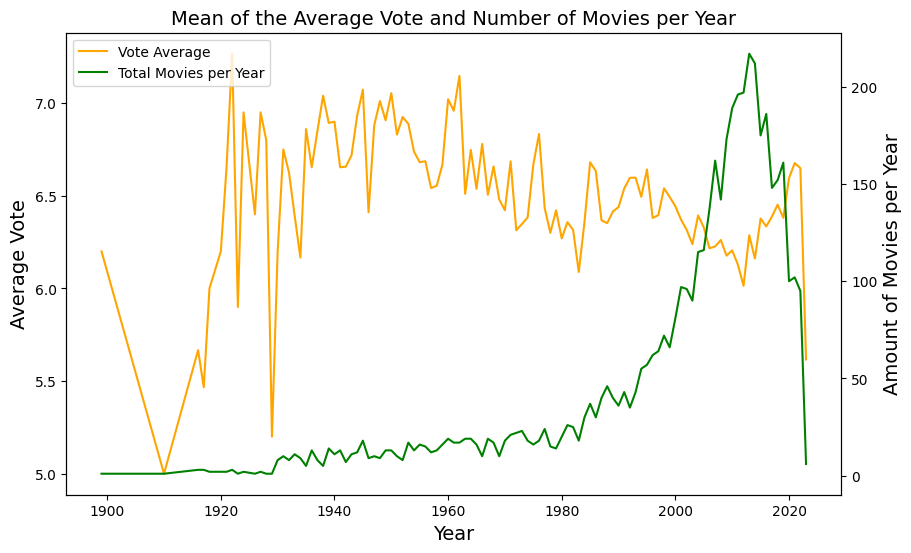

In [94]:
# Create the plot with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Axis 1: Average Vote
ax1.plot(
    df["year"],
    df["average_vote"],
    "-",
    label="Vote Average",
    color="orange",
    alpha=1
)
ax1.set_xlabel("Year", size=14)
ax1.set_ylabel("Average Vote", size=14)

# Axis 2: Movie Count
ax2 = ax1.twinx()
ax2.plot(
    df["year"],
    df["total_movies"],
    "-",
    label="Total Movies per Year",
    color="green",
    alpha=1
)
ax2.set_ylabel("Amount of Movies per Year", size=14)

# Title
plt.title("Mean of the Average Vote and Number of Movies per Year", size=14)

# legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

# Display the plot
plt.show()


2. a <br>
 Return the title of all movies that belong to the genre 'Western', have a bechdel rating of at least 1 and were the rating is not considered to be dubious. Sort them ascendingly by their release date. <br>
Hint: Check out 'ORDER BY'

In [105]:
db = pymysql.connect(
    host="localhost",
    user="liane_mysql",
    password="OR-4xozme",
    database="bechdel_movies",
    local_infile=1  # Enables local file loading

)

try:
    cursor = db.cursor()

    cursor.execute('SELECT title \
                   FROM movies \
                   JOIN movie2genres ON movies.movie_id = movie2genres.movie_id \
                   JOIN genres ON movie2genres.genre_id = genres.id \
                   WHERE bechdel_rating >= 1 AND bechdel_dubious = 0 AND genres.name = "Western" \
                   ORDER BY movies.release_date ASC;')
    result1 = cursor.fetchall()

finally:
    db.close()

df = pd.DataFrame(result1) 
df

,0
0,Cimarron
1,Jesse James
2,Stagecoach
3,Dodge City
4,Destry Rides Again
...,...
120,The Ballad of Buster Scruggs
121,The Legend of 5 Mile Cave
122,News of the World
123,The World to Come


2. b <br>
Return the title of all movies that belong to the genre 'Western' __and to the genre 'Drama'__, have a bechdel rating of at least 1 and were the rating is not considered to be dubious. Sort them ascendingly by their release date. <br>

In [110]:
db = pymysql.connect(
    host="localhost",
    user="liane_mysql",
    password="OR-4xozme",
    database="bechdel_movies",
    local_infile=1  # Enables local file loading

)

try:
    cursor = db.cursor()

    cursor.execute('SELECT title \
                   FROM movies m\
                   JOIN movie2genres gm ON m.movie_id = gm.movie_id \
                   JOIN genres g ON gm.genre_id = g.id \
                   LEFT JOIN movie2genres gm2 ON gm2.movie_id = m.movie_id \
                   JOIN genres g2 ON g2.id = gm2.genre_id \
                   WHERE g.name = "Western" AND bechdel_rating = 3 AND bechdel_dubious = 0 AND g2.name = "Drama" \
                   ORDER BY release_date ASC;')
    result1 = cursor.fetchall()

finally:
    db.close()

df = pd.DataFrame(result1) 
df

,0
0,Cimarron
1,Westward the Women
2,Seven Brides for Seven Brothers
3,Whom God Forgives
4,The Misfits
5,McCabe & Mrs. Miller
6,Even Cowgirls Get the Blues
7,Legends of the Fall
8,The Three Burials of Melquiades Estrada
9,Love Takes Wing


3. What is the title, year, bechdel rating and name(s) of the directors of the 10 movies with the highst vote_average in the database? <br>
Hint: Check out 'DISTINCT' and 'LIMIT'. <br>

NOTE: directors are doubled in this list

In [117]:
db = pymysql.connect(
    host="localhost",
    user="liane_mysql",
    password="OR-4xozme",
    database="bechdel_movies",
    local_infile=1  # Enables local file loading

)

try:
    cursor = db.cursor()

    cursor.execute("""SELECT DISTINCT (m.title), m.year, m.bechdel_rating, d.name, m.vote_average 
                   FROM movies m
                   JOIN movies2directors md ON md.movie_id = m.movie_id 
                   JOIN directors d ON d.id = md.director_id
                   ORDER BY m.vote_average DESC 
                   LIMIT 10 
                   ;""")
    result3 = cursor.fetchall()

finally:
    db.close()

pd.DataFrame(result3, columns=['title', 'year', 'bechdel_rating', 'name', 'vote_avg'])

,title,year,bechdel_rating,name,vote_avg
0,Thespians,2010,3,Warren Skeels,10.0
1,Vino Veritas,2013,3,Sarah Knight,10.0
2,Nosferatu in Love,2014,0,Peter Straughan,10.0
3,Extirpator of Idolatries,2016,3,Manuel Siles,10.0
4,El zoo d’en Pitus,2000,3,Mireia Ros,10.0
5,On the Trail of Igor Rizzi,2006,0,Noël Mitrani,9.5
6,Helen,2020,1,André Meirelles Collazzo,9.5
7,New York City Opera: A Little Night Music,1990,3,Kirk Browning,9.2
8,Bliss!,2016,3,Rita Osei,9.0
9,"Fanny, Annie & Danny",2011,3,Chris Brown,9.0



4. a<br>
What is the average bechdel rating for each genre?<br>
Hint: Check out aggregation in SQL, especially 'GROUP BY' <br>

__Please, add a visualisation of the data.__

In [124]:
db = pymysql.connect(
    host="localhost",
    user="liane_mysql",
    password="OR-4xozme",
    database="bechdel_movies",
    local_infile=1  # Enables local file loading

)

try:
    cursor = db.cursor()

    query = """
    SELECT g.name, AVG(bechdel_rating)
    FROM movies m
    JOIN movie2genres mg ON m.movie_id = mg.movie_id
    JOIN genres g ON mg.genre_id = g.id
    GROUP BY g.name;
    """

    cursor.execute(query)
    result = cursor.fetchall()

finally:
    db.close()

df = pd.DataFrame(result, columns=['genre', 'avg_bechdel_rating'])
df

,genre,avg_bechdel_rating
0,Adventure,1.8811
1,Fantasy,2.1238
2,Animation,2.0294
3,Drama,2.2109
4,Horror,2.2926
5,Action,1.7976
6,Comedy,2.2487
7,History,2.0157
8,Western,1.3793
9,Thriller,2.0138


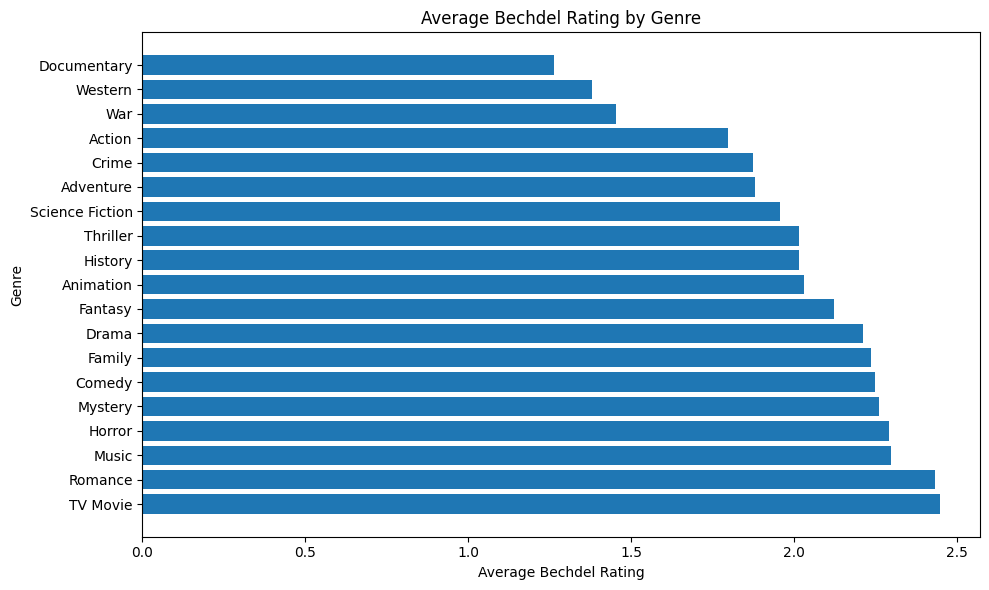

In [125]:
# Sort for nicer visualization
df = df.sort_values("avg_bechdel_rating", ascending=False)

# Create bar plot
plt.figure(figsize=(10, 6))
plt.barh(df["genre"], df["avg_bechdel_rating"])

# Labels and title
plt.xlabel("Average Bechdel Rating")
plt.ylabel("Genre")
plt.title("Average Bechdel Rating by Genre")

# Improve layout
plt.tight_layout()

plt.show()

4. b <br>
What can you add to the query in 4a to only get the genre with the highest (lowest) average bechdel rating? <br>
Write one query for each - lowerst and highest.

In [132]:
db = pymysql.connect(
    host="localhost",
    user="liane_mysql",
    password="OR-4xozme",
    database="bechdel_movies",
    local_infile=1  # Enables local file loading

)

try:
    cursor = db.cursor()

    query = """
    SELECT g.name, AVG(bechdel_rating) AS avg_bechdel_rating
    FROM movies m
    JOIN movie2genres mg ON m.movie_id = mg.movie_id
    JOIN genres g ON mg.genre_id = g.id
    GROUP BY g.name
    ORDER BY avg_bechdel_rating ASC 
    LIMIT 1
    ;
    """

    cursor.execute(query)
    result = cursor.fetchall()

finally:
    db.close()

pd.DataFrame(result, columns=["genre", "avg_bechdel_rating"])

,genre,avg_bechdel_rating
0,Documentary,1.2642


In [133]:
db = pymysql.connect(
    host="localhost",
    user="liane_mysql",
    password="OR-4xozme",
    database="bechdel_movies",
    local_infile=1  # Enables local file loading

)

try:
    cursor = db.cursor()

    query = """
    SELECT g.name, AVG(bechdel_rating) AS avg_bechdel_rating
    FROM movies m
    JOIN movie2genres mg ON m.movie_id = mg.movie_id
    JOIN genres g ON mg.genre_id = g.id
    GROUP BY g.name
    ORDER BY avg_bechdel_rating DESC 
    LIMIT 1
    ;
    """

    cursor.execute(query)
    result = cursor.fetchall()

finally:
    db.close()

pd.DataFrame(result, columns=["genre", "avg_bechdel_rating"])

,genre,avg_bechdel_rating
0,TV Movie,2.4481


5. __Reflection on the data__ <br>
Please, write a few sentences about potential issues with the data and how it reflects in the results aquired above. Could there be any bias in the data? How would that bias be manifested? How could we check for that bias?

***
# Part 4 - Bonus
### The Mondial Database

## Task 4.1 
In this task we will work with the [Mondial Database](https://www.dbis.informatik.uni-goettingen.de/Mondial/). The database has been constructed for teaching purposes and we will use the version provided by the Institute for Informatics of the the Georg-August-Universität in Göttingen, Germany.

The database consists of information about countries, their cities and their geography. You can find plenty of description of the database on the website linked above. Especially helpful for writing queries is the [referential dependency diagram](https://www.dbis.informatik.uni-goettingen.de/Mondial/mondial-abh.pdf) <br>

Using the two SQL scripts provided (mondial-schema-sqlite.sql and mondial-inputs-sqlite.sql) please generate the database locally on your machine using the sqlite3 package and load in the data. 

In [2]:
# ensure the database is empty
try:
    # Connect to the SQLite database
    conn = sqlite3.connect("data/mondial.db")
    cursor = conn.cursor()

    # Start a transaction
    cursor.execute("BEGIN TRANSACTION;")
    # Drop tables if they already exist to avoid errors
    cursor.execute("DROP TABLE IF EXISTS country;")
    cursor.execute("DROP TABLE IF EXISTS city;")
    cursor.execute("DROP TABLE IF EXISTS province;")
    cursor.execute("DROP TABLE IF EXISTS economy;")
    cursor.execute("DROP TABLE IF EXISTS population;")
    cursor.execute("DROP TABLE IF EXISTS politics;")
    cursor.execute("DROP TABLE IF EXISTS language;")
    cursor.execute("DROP TABLE IF EXISTS religion;")
    cursor.execute("DROP TABLE IF EXISTS ethnicGroup;")
    cursor.execute("DROP TABLE IF EXISTS continent;")
    cursor.execute("DROP TABLE IF EXISTS borders;")
    cursor.execute("DROP TABLE IF EXISTS encompasses;")
    cursor.execute("DROP TABLE IF EXISTS organization;")
    cursor.execute("DROP TABLE IF EXISTS isMember;")
    cursor.execute("DROP TABLE IF EXISTS mountain;")
    cursor.execute("DROP TABLE IF EXISTS desert;")
    cursor.execute("DROP TABLE IF EXISTS island;")
    cursor.execute("DROP TABLE IF EXISTS lake;")
    cursor.execute("DROP TABLE IF EXISTS sea;")
    cursor.execute("DROP TABLE IF EXISTS river;")
    cursor.execute("DROP TABLE IF EXISTS geo_mountain;")
    cursor.execute("DROP TABLE IF EXISTS geo_desert;")
    cursor.execute("DROP TABLE IF EXISTS geo_island;")
    cursor.execute("DROP TABLE IF EXISTS geo_river;")
    cursor.execute("DROP TABLE IF EXISTS geo_sea;")
    cursor.execute("DROP TABLE IF EXISTS geo_lake;")
    cursor.execute("DROP TABLE IF EXISTS geo_source;")
    cursor.execute("DROP TABLE IF EXISTS geo_estuary;")
    cursor.execute("DROP TABLE IF EXISTS mergesWith;")
    cursor.execute("DROP TABLE IF EXISTS located;")
    cursor.execute("DROP TABLE IF EXISTS locatedOn;")
    cursor.execute("DROP TABLE IF EXISTS islandIn;")
    cursor.execute("DROP TABLE IF EXISTS mountainOnIsland;")

    # Commit the transaction
    conn.commit()
    print("Query successfully!")

except sqlite3.Error as e:
    print(f"An error occurred: {e}")

finally:
    # Close the connection
    if conn:
        conn.close()

Query successfully!


In [3]:
# load schema

with sqlite3.connect("data/mondial.db") as conn:
    cursor = conn.cursor()
    with open("data/mondial-schema-sqlite.sql", "r") as file:
        sql_script = file.read()
    cursor.executescript(sql_script)
    conn.commit()  # Explicitly commit before closing

print("Schema loaded successfully!")

# Commit and close
conn.close()

Schema loaded successfully!


In [4]:
# Insert the data
# make sure the data is unzipped before inserting it to the db

with sqlite3.connect("data/mondial.db") as conn:
    cursor = conn.cursor()
    with open("data/mondial-inputs-sqlite.sql", "r") as file:
        sql_script = file.read()
    cursor.executescript(sql_script)
    conn.commit()  # Explicitly commit before closing

print("Data loaded successfully!")

# Commit and close
conn.close()

Data loaded successfully!


In [5]:
# Print all tables:

conn = sqlite3.connect('data/mondial.db')
cursor = conn.cursor()


# Query to fetch all table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

# Print table names
print("Tables in the database:")
for table in tables:
    print(table[0])  # Extract table name from the tuple

# Close the connection
conn.close()

Tables in the database:
country
city
province
economy
population
politics
language
religion
ethnicGroup
continent
borders
encompasses
organization
isMember
mountain
desert
island
lake
sea
river
geo_mountain
geo_desert
geo_island
geo_river
geo_sea
geo_lake
geo_source
geo_estuary
mergesWith
located
locatedOn
islandIn
mountainOnIsland


In [6]:
# Check the upload by querying the last table - mountainOnIsland
try:
    # Connect to the SQLite database
    conn = sqlite3.connect("data/mondial.db")
    cursor = conn.cursor()

    cursor.execute("SELECT * FROM mountainOnIsland;")
    results = cursor.fetchall()

    # Commit the transaction
    print("Query successfully!")

except sqlite3.Error as e:
    print(f"An error occurred: {e}")

finally:
    # Close the connection
    if conn:
        conn.close()

pd.DataFrame(results, columns= ['mountain', 'island'])

Query successfully!


,mountain,island
0,Oeraefajoekull,Iceland
1,Snoefell,Iceland
2,Ben Nevis,Great Britain
3,Monte Cinto,Corse
4,Etna,Sicilia
...,...,...
62,La Soufriere,Basse-Terre
63,Soufriere Hills,Montserrat
64,Soufriere,Saint Vincent
65,Morne Diablotins,Dominica


## Task 4.2 

Please write queries for the following questions:

1. Through which of the provinces of "Germany" does the "Rhein" flow?


In [ ]:
# Your code

2. 
    a. For all continents return the name of the continent as well as the number of countries within each continent. (hint: you might need to use aggregation)


In [ ]:
# Your code

2. b. Include a statement ensuring only highly populated continents (more than 50 inhabitants/km²) are returned. (hint: use the provided total area for this)



In [ ]:
# Your code

3. Return the capitals of all EU-countries, the country name and the population sorted (descending) by the population.

In [ ]:
# Your code